In [1]:
import numpy as np
import matplotlib.pyplot as plt

from firedrake import *
import dean_kawasaki_DG as dkDG
from firedrake.pyplot import plot as fd_plot

In [2]:
LENGTH = 2.0 * np.pi

In [3]:
def _normalised_two_bump_initial_condition(
    V,
    x,
    concentration,
    separation,
):
    centre = np.pi
    left_centre = centre - separation
    right_centre = centre + separation

    raw_density = (
        exp(concentration * cos(x - left_centre))
        + exp(concentration * cos(x - right_centre))
    )

    rho = Function(V, name="rho_initial")
    rho.interpolate(raw_density)

    mass = assemble(rho * dx)
    rho.assign(rho / mass)

    return rho


def _positive_part(source, target):
    target.dat.data[:] = np.maximum(source.dat.data_ro, 0.0)

In [4]:
class _CosineInteraction1D:
    def __init__(self, mesh, interaction_strength):
        (x,) = SpatialCoordinate(mesh)

        self.x = x
        self.interaction_strength = Constant(
            float(interaction_strength)
        )

        # These Constants are updated whenever rho changes.
        self.cosine_moment = Constant(0.0)
        self.sine_moment = Constant(0.0)

        grad_W_convolution_rho = self.interaction_strength * (
            sin(x) * self.cosine_moment
            - cos(x) * self.sine_moment
        )

        # Physical velocity:
        #
        #     a[rho] = -(W' * rho).
        self.transport_velocity = as_vector(
            [-grad_W_convolution_rho]
        )

    def update(self, rho):
        cosine_moment = assemble(
            rho * cos(self.x) * dx
        )
        sine_moment = assemble(
            rho * sin(self.x) * dx
        )

        self.cosine_moment.assign(cosine_moment)
        self.sine_moment.assign(sine_moment)

    def order_parameter(self):
        cosine_moment = float(self.cosine_moment)
        sine_moment = float(self.sine_moment)

        return np.sqrt(
            cosine_moment**2 + sine_moment**2
        )

In [5]:
def _advection_form(mesh, u, v, velocity, flux):
    n = FacetNormal(mesh)

    volume = -inner(
        u * velocity,
        grad(v),
    ) * dx

    if flux == "central":
        facet = inner(
            avg(u * velocity),
            jump(v, n),
        ) * dS

        return volume + facet

    if flux != "upwind":
        raise ValueError(
            "flux must be either 'central' or 'upwind'"
        )

    # Orientation is taken with respect to n("+").
    normal_velocity = dot(
        avg(velocity),
        n("+"),
    )

    upwind_value = conditional(
        normal_velocity >= 0.0,
        u("+"),
        u("-"),
    )

    facet = (
        normal_velocity
        * upwind_value
        * jump(v)
        * dS
    )

    return volume + facet

In [6]:
def _solve_cg(
    nx,
    degree,
    dt,
    final_time,
    kappa,
    interaction_strength,
    initial_concentration,
    initial_separation,
    num_particles,
    seed,
    noise_gradient,
    picard_iterations,
    picard_tolerance,
    save_times,
    stochastic=True,
):
    mesh = PeriodicIntervalMesh(
        ncells=nx,
        length=LENGTH,
    )

    (x,) = SpatialCoordinate(mesh)

    V = FunctionSpace(
        mesh,
        "CG",
        degree,
    )

    rho0 = _normalised_two_bump_initial_condition(
        V,
        x,
        concentration=initial_concentration,
        separation=initial_separation,
    )

    rho_initial = rho0.copy(deepcopy=True)

    rho_pos = Function(
        V,
        name="cg_positive",
    )

    rho_guess = Function(
        V,
        name="cg_picard_guess",
    )

    rho = TrialFunction(V)
    v = TestFunction(V)

    interaction = _CosineInteraction1D(
        mesh,
        interaction_strength,
    )
    interaction.update(rho0)

    velocity = interaction.transport_velocity

    noise = None

    if stochastic:
        noise = dkDG.DeanKawasakiNoise(
            mesh,
            V,
            degree,
            dt,
            kappa,
            num_particles,
            "equispaced",
            gradient=noise_gradient,
            seed=seed,
        )

    mass_form = inner(rho, v) * dx

    diffusion_form = (
        kappa
        * inner(grad(rho), grad(v))
        * dx
    )

    advection_form = -inner(
        rho * velocity,
        grad(v),
    ) * dx

    a = (
        mass_form
        + dt * diffusion_form
        + dt * advection_form
    )

    L = inner(rho0, v) * dx

    if noise is not None:
        L += noise.variational_form(v)

    rho_new = Function(
        V,
        name="cg",
    )

    problem = LinearVariationalProblem(
        a,
        L,
        rho_new,
        constant_jacobian=False,
    )

    solver = LinearVariationalSolver(
        problem,
        solver_parameters={
            "mat_type": "aij",
            "ksp_type": "preonly",
            "pc_type": "lu",
        },
    )

    num_steps = int(
        round(final_time / dt)
    )

    times = np.linspace(
        0.0,
        final_time,
        num_steps + 1,
    )

    num_steps = int(round(final_time / dt))

    save_steps = dkDG.prepare_saveat(
        save_times,
        dt,
        final_time
    )

    if save_steps is None:
        save_steps = {num_steps}
    else:
        save_steps = set(save_steps)

    snapshots = {}

    if 0 in save_steps:
        time = 0.0

        snapshot = rho0.copy(deepcopy=True)
        snapshot.rename(f"rho_t_{time:g}")

        snapshots[time] = snapshot

    for step in range(1, num_steps + 1):
        if noise is not None:
            _positive_part(
                rho0,
                rho_pos,
            )
            noise.sample(rho_pos)

        rho_guess.assign(rho0)

        for _ in range(picard_iterations):
            interaction.update(rho_guess)

            solver.solve()

            difference = norm(
                rho_new - rho_guess
            )
            scale = max(
                norm(rho_new),
                1.0e-14,
            )

            rho_guess.assign(rho_new)

            if difference <= picard_tolerance * scale:
                break

        # rho0 now represents the solution at time step * dt.
        rho0.assign(rho_new)

        if step in save_steps:
            time = step*dt

            snapshot = rho0.copy(deepcopy=True)
            snapshot.rename(f"rho_t_{time:g}")

            snapshots[time] = snapshot

    return {
        "solution": rho0,
        "initial": rho_initial,
        "snapshots": snapshots,
        "times": times,
    }

In [7]:
def _solve_dg(
    nx,
    degree,
    dt,
    final_time,
    kappa,
    interaction_strength,
    initial_concentration,
    initial_separation,
    num_particles,
    seed,
    noise_gradient,
    flux,
    picard_iterations,
    picard_tolerance,
    save_times,
    stochastic=True,
):
    mesh = PeriodicIntervalMesh(
        ncells=nx,
        length=LENGTH,
    )

    (x,) = SpatialCoordinate(mesh)

    V = FunctionSpace(
        mesh,
        "DG",
        degree,
    )

    rho0 = _normalised_two_bump_initial_condition(
        V,
        x,
        concentration=initial_concentration,
        separation=initial_separation,
    )

    rho_initial = rho0.copy(deepcopy=True)

    rho_pos = Function(
        V,
        name=f"dg_{flux}_positive",
    )

    rho_guess = Function(
        V,
        name=f"dg_{flux}_picard_guess",
    )

    rho = TrialFunction(V)
    v = TestFunction(V)

    interaction = _CosineInteraction1D(
        mesh,
        interaction_strength,
    )
    interaction.update(rho0)

    velocity = interaction.transport_velocity

    eta = 20.0

    noise = None

    if stochastic:
        noise = dkDG.DeanKawasakiNoise(
            mesh,
            V,
            degree,
            dt,
            kappa,
            num_particles,
            "equispaced",
            gradient=noise_gradient,
            seed=seed,
        )

    diffusion = dkDG.sipdg_diffusion_form(
        mesh,
        rho,
        v,
        eta,
    )

    advection = _advection_form(
        mesh,
        rho,
        v,
        velocity,
        flux,
    )

    a = (
        inner(rho, v) * dx
        + dt * kappa * diffusion
        + dt * advection
    )

    L = inner(rho0, v) * dx

    if noise is not None:
        L += noise.variational_form(v)

    rho_new = Function(
        V,
        name=f"dg_{flux}",
    )

    problem = LinearVariationalProblem(
        a,
        L,
        rho_new,
        constant_jacobian=False,
    )

    solver = LinearVariationalSolver(
        problem,
        solver_parameters={
            "mat_type": "aij",
            "ksp_type": "preonly",
            "pc_type": "lu",
        },
    )

    num_steps = int(
        round(final_time / dt)
    )

    times = np.linspace(
        0.0,
        final_time,
        num_steps + 1,
    )

    num_steps = int(round(final_time / dt))

    save_steps = dkDG.prepare_saveat(
        save_times,
        dt,
        final_time,
    )

    if save_steps is None:
        save_steps = {num_steps}
    else:
        save_steps = set(save_steps)

    snapshots = {}

    if 0 in save_steps:
        time = 0.0

        snapshot = rho0.copy(deepcopy=True)
        snapshot.rename(f"rho_t_{time:g}")

        snapshots[time] = snapshot

    for step in range(1, num_steps + 1):
        if noise is not None:
            _positive_part(
                rho0,
                rho_pos,
            )
            noise.sample(rho_pos)

        rho_guess.assign(rho0)

        for _ in range(picard_iterations):
            interaction.update(rho_guess)

            solver.solve()

            difference = norm(
                rho_new - rho_guess
            )
            scale = max(
                norm(rho_new),
                1.0e-14,
            )

            rho_guess.assign(rho_new)

            if difference <= picard_tolerance * scale:
                break

        # rho0 now represents the solution at time step * dt.
        rho0.assign(rho_new)

        if step in save_steps:
            time = step*dt

            snapshot = rho0.copy(deepcopy=True)
            snapshot.rename(f"rho_t_{time:g}")

            snapshots[time] = snapshot

    return {
        "solution": rho0,
        "initial": rho_initial,
        "snapshots": snapshots,
        "times": times,
    }

In [8]:
def run(
    degree=1,
    stochastic=False,
):
    params = {
        "nx": 159,
        "degree": 1,
        "dt": 2.0e-4,
        "final_time": 0.35,
        "kappa": 1.0e-2,
        "interaction_strength": 16.0,
        "initial_concentration": 18.0,
        "initial_separation": 0.8,
        "num_particles": 500,
        "seed": 123,
        "noise_gradient": "full",
        "picard_iterations": 5,
        "picard_tolerance": 1.0e-10,
        "save_times": [0.0, 0.08, 0.18, 0.35],
        "stochastic": True,
    }

    results = {
        "cG": _solve_cg(
            **params,
        ),
        "dG_upwind": _solve_dg(
            flux="upwind",
            **params,
        ),
    }

    return results

In [9]:
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.labelsize": 14,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.linewidth": 0.8,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": [
            "Computer Modern Roman"
        ],
        "mathtext.fontset": "cm",
        "text.latex.preamble": (
            r"\usepackage{amsmath,amssymb}"
        ),
    }
)

In [10]:
results = run(
    degree=1,
    stochastic=True,
)

snapshot_times = list(
    results["dG_upwind"]["snapshots"].keys()
)

/tmp/ipykernel_4327/535513088.py:192: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


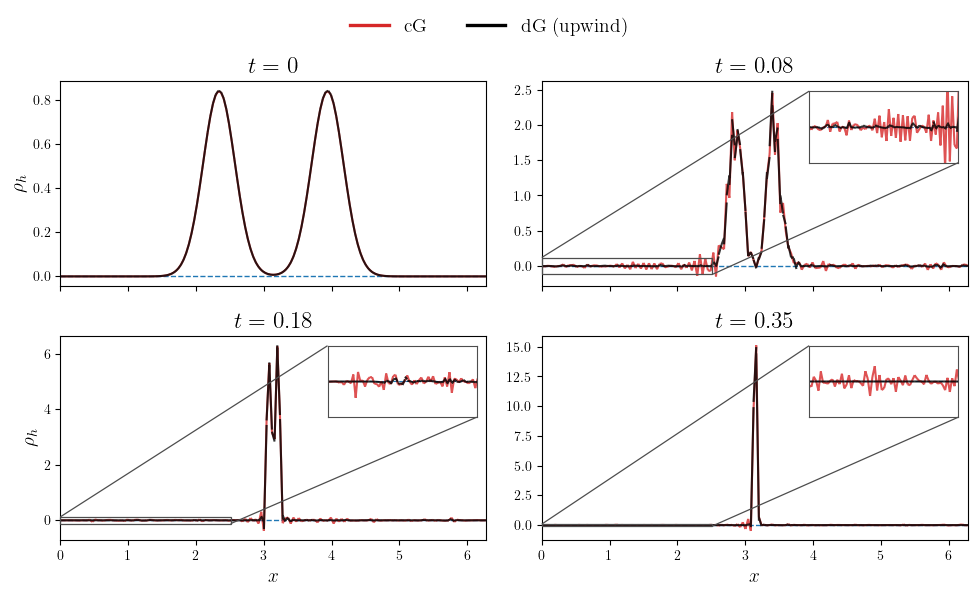

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


fig, axes = plt.subplots(
    2,
    2,
    figsize=(10.0, 6.0),
    sharex=True,
    sharey=False,
)

axes = axes.ravel()

# Vertical ranges used in the zoomed insets.
# Dictionary keys refer to panel indices:
#   0 = top-left, 1 = top-right,
#   2 = bottom-left, 3 = bottom-right.
inset_ylims = {
    1: (-0.12, 0.12),
    2: (-0.12, 0.12),
    3: (-0.08, 0.08),
}

# Spatial interval displayed in each inset.
inset_xlim = (0.0, 0.8 * np.pi)


for index, (ax, time) in enumerate(
    zip(axes, snapshot_times)
):
    rho_cg = results["cG"]["snapshots"][time]
    rho_dg = results["dG_upwind"]["snapshots"][time]

    # Main cG solution.
    fd_plot(
        rho_cg,
        axes=ax,
        edgecolor="tab:red",
        alpha=0.8,
    )

    # Main upwind dG solution.
    fd_plot(
        rho_dg,
        axes=ax,
        edgecolor="black",
        alpha=0.8,
    )

    ax.axhline(
        0.0,
        color="tab:blue",
        linestyle="--",
        linewidth=1.0,
        zorder=0,
    )

    ax.set_title(
        rf"$t={time:g}$"
    )

    ax.set_xlim(
        0.0,
        2.0 * np.pi,
    )

    # Add zoomed insets to panels 2, 3 and 4.
    if index in inset_ylims:
        inset_ylim = inset_ylims[index]

        # Ensure the complete source rectangle is visible on the main axes.
        main_ymin, main_ymax = ax.get_ylim()
        ax.set_ylim(
            min(main_ymin, inset_ylim[0]),
            main_ymax,
        )

        axins = inset_axes(
            ax,
            width="35%",
            height="35%",
            loc="upper right",
            borderpad=0.5,
        )

        fd_plot(
            rho_cg,
            axes=axins,
            edgecolor="tab:red",
            alpha=0.8,
        )

        fd_plot(
            rho_dg,
            axes=axins,
            edgecolor="black",
            alpha=0.8,
        )

        axins.axhline(
            0.0,
            color="tab:blue",
            linestyle="--",
            linewidth=0.8,
            zorder=0,
        )

        axins.set_xlim(
            *inset_xlim
        )

        axins.set_ylim(
            *inset_ylim
        )

        # Remove ticks and tick labels from the inset.
        axins.set_xticks([])
        axins.set_yticks([])

        axins.tick_params(
            axis="both",
            which="both",
            bottom=False,
            top=False,
            left=False,
            right=False,
            labelbottom=False,
            labelleft=False,
        )

        for spine in axins.spines.values():
            spine.set_linewidth(0.8)
            spine.set_color("0.3")

        # Draw the source rectangle and explicit connector lines.
        source_box, connector_1, connector_2 = mark_inset(
            ax,
            axins,
            loc1=2,
            loc2=4,
            fc="none",
            ec="0.3",
            lw=0.9,
        )

        source_box.set_zorder(5)
        source_box.set_clip_on(False)

        for connector in (connector_1, connector_2):
            connector.set_zorder(5)
            connector.set_clip_on(False)


# Axis labels.
for ax in axes[2:]:
    ax.set_xlabel(r"$x$")

for ax in axes[::2]:
    ax.set_ylabel(r"$\rho_h$")


# Shared legend.
handles = [
    Line2D(
        [0],
        [0],
        color="tab:red",
        lw=2.4,
        label="cG",
    ),
    Line2D(
        [0],
        [0],
        color="black",
        lw=2.4,
        label="dG (upwind)",
    ),
]

fig.legend(
    handles=handles,
    frameon=False,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.01),
)


plt.tight_layout(
    rect=[0.0, 0.0, 1.0, 0.95]
)

# plt.savefig(
#     "interaction_evolution_p1.pdf",
#     dpi=300,
#     bbox_inches="tight",
# )

plt.show()